# 🚕 Taxi Dataset Exploratory Data Analysis (EDA)

This notebook explores the NYC Taxi dataset using PySpark.

### Goals:
- Understand dataset structure
- Check missing values
- Analyze distributions
- Visualize key relationships (distance vs fare, trips by hour)

In [26]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Taxi EDA") \
    .getOrCreate()

## 📂 Load Dataset

We load the raw parquet file and inspect its structure.

In [27]:
df = spark.read.parquet("../data/taxi.parquet")

df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       2| 2025-02-01 00:12:18|  2025-02-01 00:32:33|              3|         3.12|         1|                 N|         246|    

## 📊 Dataset Overview

We inspect schema and size to understand data scale and structure before preprocessing.

In [28]:
print("Rows:", df.count())
print("Columns:", len(df.columns))
df.printSchema()

Rows: 3577543
Columns: 20
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



## ❓ Missing Values Check

We count missing values in each column.

In [29]:
from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       0|                   0|                    0|         806937|            0|    806937|            806937|           0|    

# FEATURE ENGINEERING

- Calculate trip duration in minutes from pickup and dropoff time
- Remove invalid trips (duration < 0 or > 300 minutes)
- Extract pickup hour
- Extract day of week
- Create weekend flag (1 = weekend, 0 = not)
- Calculate average speed (km/h)
- Remove unrealistic speeds (> 120 km/h)

In [30]:
# ================= FEATURE ENGINEERING =================

from pyspark.sql.functions import (
    col,
    unix_timestamp,
    hour,
    dayofweek,
    when
)

# Trip duration in minutes
df = df.withColumn(
    "trip_duration",
    (
        unix_timestamp("tpep_dropoff_datetime") -
        unix_timestamp("tpep_pickup_datetime")
    ) / 60
)

# Remove unrealistic durations
df = df.filter(col("trip_duration") > 0)
df = df.filter(col("trip_duration") < 300)

# Pickup hour
df = df.withColumn(
    "hour",
    hour("tpep_pickup_datetime")
)

# Day of week
df = df.withColumn(
    "day_of_week",
    dayofweek("tpep_pickup_datetime")
)

# Weekend flag
df = df.withColumn(
    "is_weekend",
    when(col("day_of_week").isin([1, 7]), 1).otherwise(0)
)

# Average speed (distance per hour)
df = df.withColumn(
    "avg_speed",
    col("trip_distance") / (col("trip_duration") / 60)
)

# Remove unrealistic speeds
df = df.filter(col("avg_speed") < 120)

## 📉 Convert Sample for Visualization

We convert a sample of the data to Pandas for plotting.

In [31]:
pdf = df.sample(False, 0.1, seed=42).toPandas()

## 📊 Distance vs Fare Relationship

We visualize how trip distance affects fare amount.

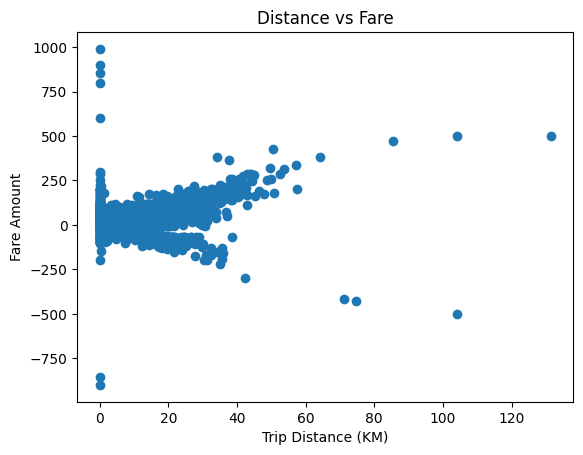

In [32]:

import matplotlib.pyplot as plt

plt.scatter(pdf["trip_distance"], pdf["fare_amount"])
plt.xlabel("Trip Distance (KM)")
plt.ylabel("Fare Amount")
plt.title("Distance vs Fare")
plt.show()

## 🕒 Trips Distribution by Hour

We analyze when most trips happen during the day.

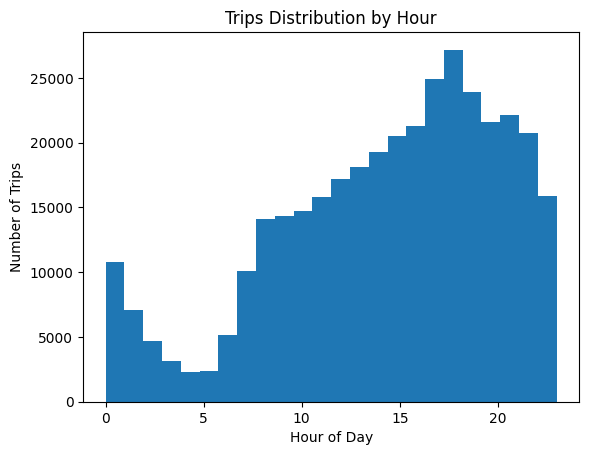

In [33]:
plt.hist(pdf["hour"], bins=24)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Trips Distribution by Hour")
plt.show()

## 📌 Summary

- Dataset contains taxi trip records
- Strong correlation between distance and fare
- Peak hours show demand patterns
- Feature engineering improves ML readiness